# Preparation

In [1]:
import numpy as np
import plotting as P
from config import create_config
import tables
from IPython.display import display, Latex

# Set up problem configuration
config = create_config()  
cache_dir = f"./cache_seed{config.seed}"
tables.save_config_table_tex(config=config, savepath="thesis/tables/config.tex")
tables.show_katex_array(tables.make_config_spec(config), caption="Problem Configuration")




<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Problem Configuration</div>

# Data Generation

<IPython.core.display.Latex object>

saving to: figures/test.pdf


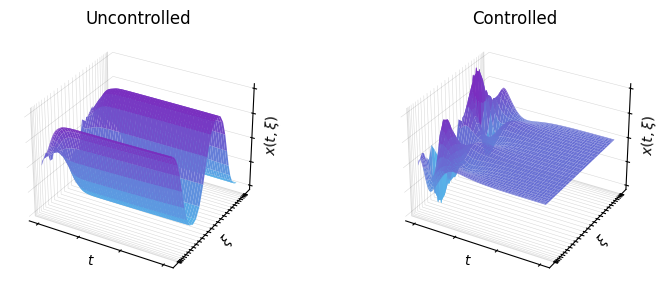

In [2]:
import matplotlib.pyplot as plt
from data import load_or_generate

data, meta = load_or_generate(config, n_trajectories=50, controller=config.ocp.LQR, force_regen=False)

tables.save_data_summary_table_tex(config=config, data=data, savepath="thesis/tables/data_summary.tex");
tables.show_katex_array(tables.make_data_summary_spec(config, data))

fig = P.plot_3d(config=config, controller=config.ocp.LQR, savepath="figures/test.pdf")
plt.show()

# Controller Training

### LQR-Baseline

In [3]:
from controls.train import train_or_load_gradnet, TrainConfig


cfg = TrainConfig(batch_size=config.n_states, grad_clip=1.0)
tables.save_traincfg_table_tex(train_cfg=cfg, savepath="thesis/tables/traincfg.tex")
tables.show_katex_array(tables.make_traincfg_spec(cfg), caption="Training configuration")

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Training configuration</div>

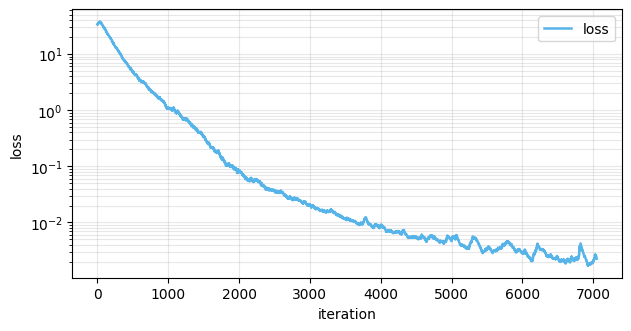

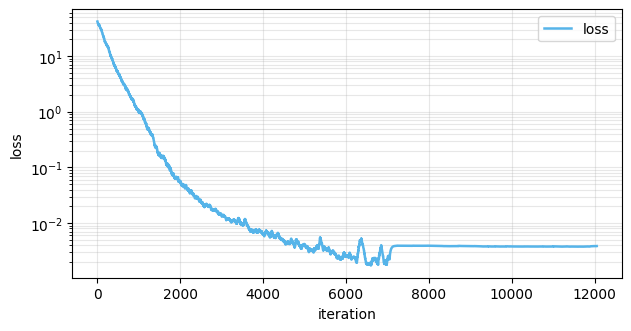

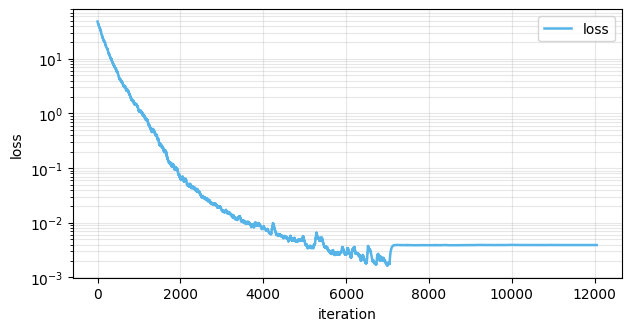

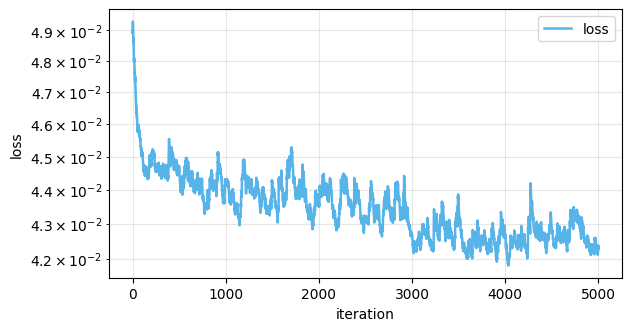

In [4]:
from controls.nn import Control

# Model 1: Plain Supervised
model1, meta1, hist1 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="supervised", adaptive=False, supervision=False, train_cfg=cfg, data=data)
ctrl1 = Control(config, grad_net=model1, use_autograd=False)
k = 1
P.plot_training_losses(iters=hist1["iters"][::k], losses=hist1["loss"][::k], logy=True, savepath="figures/loss_curve1.pdf");

# Model 2: Hybrid
model2, meta2, hist2 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="hybrid", adaptive=False, supervision=False, train_cfg=cfg, data=data)
ctrl2 = Control(config, grad_net=model2, use_autograd=False)
k = 1
P.plot_training_losses(iters=hist2["iters"][::k], losses=hist2["loss"][::k], logy=True, savepath="figures/loss_curve2.pdf");

# Model 3: Adaptive Hybrid
model3, meta3, hist3 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="hybrid", adaptive=True, supervision=False, train_cfg=cfg, data=data)
ctrl3 = Control(config, grad_net=model3, use_autograd=False)
k = 1
P.plot_training_losses(iters=hist3["iters"][::k], losses=hist3["loss"][::k], logy=True, savepath="figures/loss_curve3.pdf");

# Model 4: Unsupervised with Supervised Penalty
model4, meta4, hist4 = train_or_load_gradnet(config=config, kind="gradnet", use_lqr=True, train_mode="unsupervised", adaptive=False, supervision=True, train_cfg=cfg, data=data)
ctrl4 = Control(config, grad_net=model4, use_autograd=False)
k = 1
P.plot_training_losses(iters=hist4["iters"][::k], losses=hist4["loss"][::k], logy=True, savepath="figures/loss_curve4.pdf");


# Evaluation

In [5]:
from evaluation import ic_hard, evaluate_controller
from sampling import sample_conditions

# 1. Setup Data
X_std = sample_conditions(config, n=10, seed=84)
X_hard = sample_conditions(config, n=10, seed=83, K=20, dist=5)

#X_hard, meta = ic_hard(config, n_pool=2, seed=7) # pool size can be adjusted

results = []
results += evaluate_controller(config, config.ocp.LQR, "LQR", X_std, X_hard)
results += evaluate_controller(config, ctrl1, "Model 1", X_std, X_hard)
results += evaluate_controller(config, ctrl2, "Model 2", X_std, X_hard)
results += evaluate_controller(config, ctrl3, "Model 3", X_std, X_hard)
results += evaluate_controller(config, ctrl4, "Model 4", X_std, X_hard)
# 2. Define Controllers to test
controllers = [
    (config.ocp.LQR, "LQR (Baseline)"),
    (ctrl1, "Model 1"),
    (ctrl2, "Model 2"),
    (ctrl3, "Model 3"),
    (ctrl4, "Model 4"),
]

# 3. Collect Data
all_metrics = []
for ctrl, name in controllers:
    all_metrics.extend(evaluate_controller(config, ctrl, name, X_std, X_hard))

# 4. Display as a clean Table

tables.save_results_table_tex(results=results, savepath="thesis/tables/controllers.tex")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="LQR"), caption="LQR")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 1"), caption="Model 1")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 2"), caption="Model 2")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 3"), caption="Model 3")

tables.show_katex_array(tables.make_results_spec_2row(results, controller="Model 4"), caption="Model 4")




<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> LQR</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 1</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 2</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 3</div>

<IPython.core.display.Latex object>

<div style='text-align:center; font-size:0.9em;'><b>Table.</b> Model 4</div>

## Plots

In [6]:
P.set_thesis_style()

KW = dict(config=config, controller=ctrl1, seed=0)

### Value Function

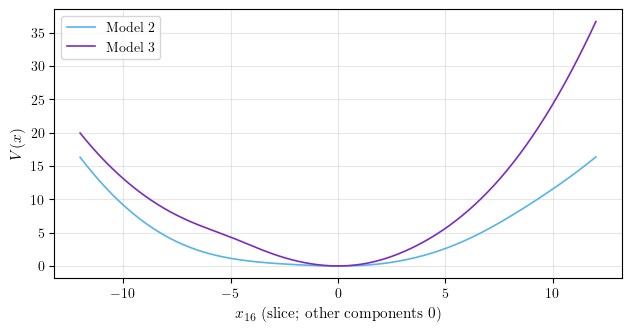

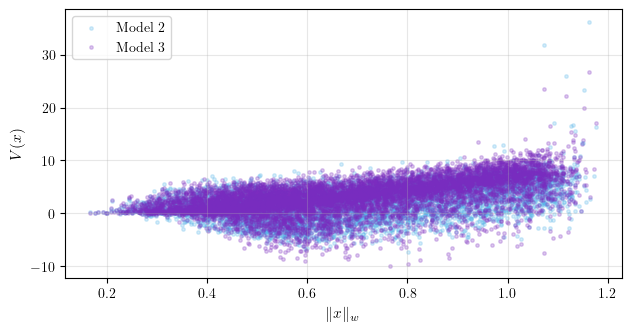

In [9]:
controllers = [("Model 2", ctrl2), ("Model 3", ctrl3)]

P.plot_value_slice(config=config, controllers=controllers, i=0.5*config.n_states, savepath="figures/V_slice.pdf")
P.plot_value_vs_state_norm(config=config, controllers=controllers, n=8000, savepath="figures/V_vs_norm.pdf")

plt.show()

### HJB-Residual

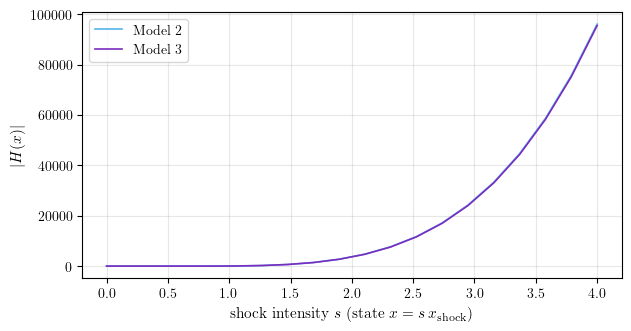

In [10]:
from plotting import plot_hjb_residual_shock_line

controllers = [("Model 2", ctrl2.grad_net), ("Model 3", ctrl3.grad_net)]
plot_hjb_residual_shock_line(config=config, controllers=controllers, savepath="figures/hjb_truth_line.pdf");

#### Flow

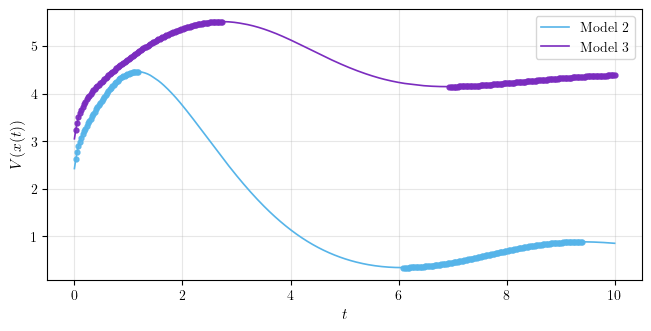

In [11]:
P.plot_value_flow(config=config, controllers=[("Model 2", ctrl2), ("Model 3", ctrl3)], seed=0, tspan=(0.0, 10.0), Nt=400, savepath="figures/V_flow.pdf");

### Value Gradient

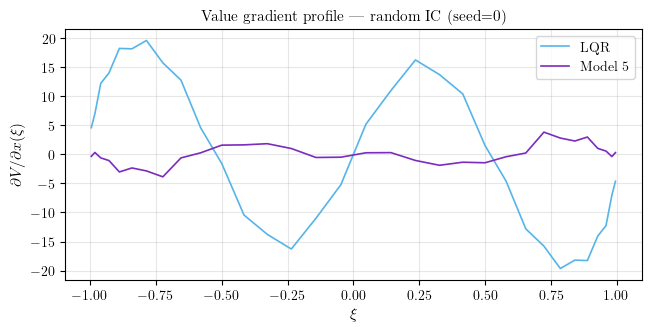

In [ ]:
P.plot_value_gradient_profile(config=config, controllers=[("LQR", config.ocp.LQR), ("Model 5", ctrl5)], which="random", hard_index=0, savepath="figures/grad_profile_hard0.pdf");

### Burgers

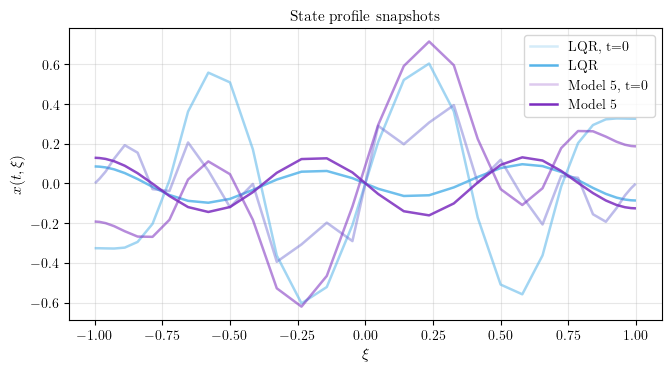

In [ ]:
P.plot_state_profile_snapshots(config=config, controllers=[("LQR", config.ocp.LQR), ("Model 5", ctrl5)], times=(0.0, 2.0, 10.0), seed=0, savepath="figures/state_snapshots.pdf");

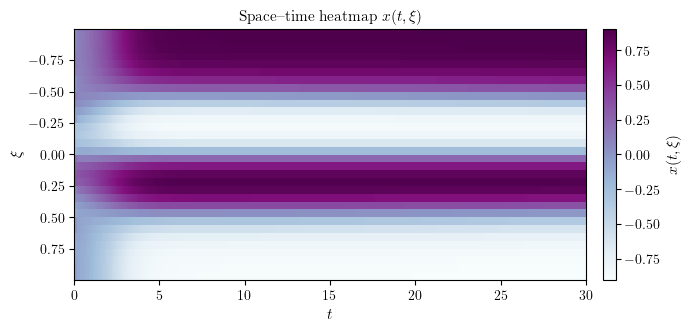

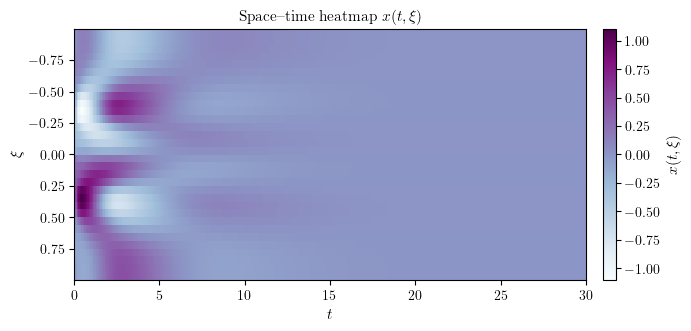

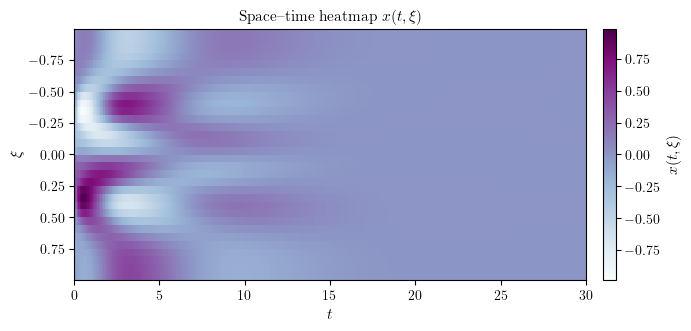

In [ ]:
P.plot_space_time_heatmap(config=config, controller=P._ZeroController(config), seed=0, tspan=(0.0, 30.0), savepath="figures/heatmap_uncontrolled.pdf");
P.plot_space_time_heatmap(config=config, controller=config.ocp.LQR, seed=0, tspan=(0.0, 30.0), savepath="figures/heatmap_LQR.pdf");
P.plot_space_time_heatmap(config=config, controller=ctrl1, seed=0, tspan=(0.0, 30.0), savepath="figures/heatmap_ctrl3.pdf");

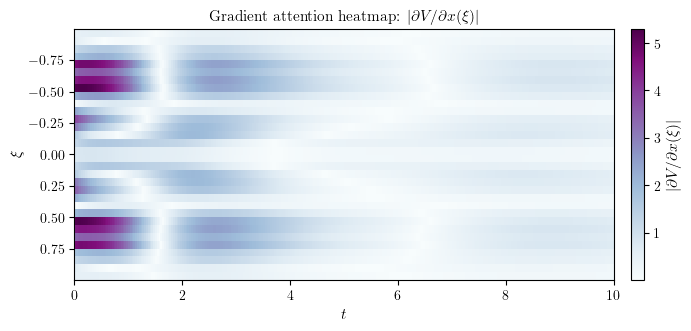

In [ ]:
P.plot_gradient_attention_heatmap(config=config, controller=ctrl1, seed=0, tspan=(0.0, 10.0), Nt=300, savepath="figures/attention_ctrl3.pdf");

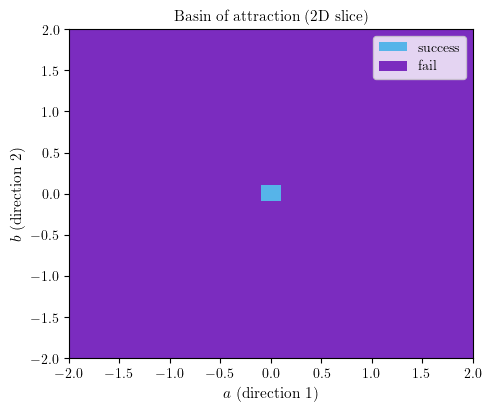

In [ ]:
P.plot_basin_2d(config=config, controller=ctrl5, dir1=np.sin(np.pi*np.asarray(config.xi).reshape(-1)), dir2=P.sample_conditions(config, n=1, seed=0, dist=1.0)[:,0], res=21, a_lim=2.0, b_lim=2.0, T=6.0, eps=2e-2, savepath="figures/basin_ctrl3_fast.pdf");